# Act 06: Backtest orientado a eventos de la estrategia SMA + Bollinger + RSI + MACD (BTC, 4 h)
**Isabela Torres Septien Uribe**

Este notebook toma la estrategia de la Act 05 (`SPEC.md`) y la corre sobre un **motor orientado a eventos** (barra por barra, no vectorizado). Además de repetir el flujo de la Act 05, agrega lo que pide la Act 06:

| # | Requisito de la Act 06 | Dónde está |
|---|---|---|
| 1 | `backtest()` como función pura en `src/backtest.py`, con cash, posición y equity explícitos | Sección 3 y prueba `test_backtest_is_pure` |
| 2 | Golden-file test: camino corto con el equity final calculado a mano | Sección 4 |
| 3 | Prueba de truncamiento del **pipeline completo** (indicadores → señales → combinación → backtest) | Sección 5 |
| 4 | Curva de equity, curva de drawdown, lista de operaciones | Secciones 7 y 8 |
| 5 | Sensibilidad a costos (Sharpe y equity contra costo de ida y vuelta de 0 a 50 bps) | Sección 10 |
| 6 | Métricas en `src/metrics.py`: drawdown máximo, Calmar, turnover, win rate teórico (p\*) contra empírico | Secciones 9 y 11 |
| 7 | Tabla de auditoría de sesgos con evidencia concreta | Sección 12 |

**Parámetros vigentes (los del código, `src/strategy.py`)**

| Bloque | Regla |
|---|---|
| Entrada C1 (tendencia) | SMA_10 > SMA_100 **y** close > BB_mid |
| Entrada C2 (momentum) | MACD > señal **y** 50 < RSI_14 < 70 **y** close < BB_high |
| Disparador | Cruce alcista del MACD sobre su señal con C1 y C2 activas |
| Salidas | SL = entrada − 4 ATR · TP = entrada + 3 ATR · break-even al ganar 1 ATR |
| Sizing | unidades = ρ × equity / (entrada − SL), ρ = 2 %, sin apalancamiento |
| Costos | 10 bps comisión + 5 bps slippage por lado (30 bps ida y vuelta) |
| Capital inicial | $100,000 |

In [1]:
import subprocess, sys
from dataclasses import replace
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display, Markdown

from src.indicators import load_bars, add_indicators
from src.strategy import Params, entry_conditions
from src.backtest import backtest, run_pipeline, with_costs, scale_costs
from src import metrics as M

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", None)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.titleweight": "bold", "font.size": 10})
BLUE, ORANGE, AQUA, VIOLET, GRAY = "#2a78d6", "#eb6834", "#1baf7a", "#4a3aa7", "#8a8984"
GOOD, BAD, WARN = "#008300", "#e34948", "#eda100"
usd = plt.FuncFormatter(lambda x, _: f"${x:,.0f}")
DATA = "data/btc_project_train.csv"
P = Params()
P

Params(rho=0.02, sl_atr=4.0, tp_atr=3.0, be_atr=1.0, rsi_low=50.0, rsi_high=70.0, commission_bps=10.0, slippage_bps=5.0, initial_cash=100000.0)

## 1. Datos: barras de 4 horas y división train / test / validation
Mismo tratamiento que la Act 05: se eliminan las filas con NaN del archivo de 5 minutos y se agregan a bloques de 4 h (00, 04, 08, 12, 16, 20 h).

In [2]:
df = load_bars(DATA, "4h")
n = len(df); a, b = int(n * 0.6), int(n * 0.8)
splits = {"Train": df.iloc[:a], "Test": df.iloc[a:b], "Validation": df.iloc[b:]}
tabla_split = pd.DataFrame({k: {"Inicio": v.index[0], "Fin": v.index[-1], "Barras": len(v),
                                "Precio inicial": v["close"].iloc[0], "Precio final": v["close"].iloc[-1],
                                "Buy & hold (%)": 100 * (v["close"].iloc[-1] / v["close"].iloc[0] - 1)}
                            for k, v in splits.items()}).T
print(f"Barras de 4 h: {len(df):,}  |  {df.index[0]}  ->  {df.index[-1]}")
tabla_split

Barras de 4 h: 3,450  |  2022-06-01 00:00:00  ->  2023-12-31 00:00:00


,Inicio,Fin,Barras,Precio inicial,Precio final,Buy & hold (%)
Train,2022-06-01 00:00:00,2023-05-15 00:00:00,2070,"31,641.48","27,259.02",-13.85
Test,2023-05-15 04:00:00,2023-09-07 00:00:00,690,"27,418.78","25,822.50",-5.82
Validation,2023-09-07 04:00:00,2023-12-31 00:00:00,690,"25,751.93","42,198.00",63.86


## 2. Pipeline: indicadores → señales → combinación
`run_pipeline()` encadena las tres etapas y entrega el resultado al motor de backtest. Todo es causal: cada valor en *t* solo usa datos hasta *t*.

In [3]:
ind = add_indicators(df)
sig = entry_conditions(ind, P)
data = ind.join(sig)
conteo = pd.DataFrame({"Barras": [sig["c1_tendencia"].sum(), sig["c2_momentum"].sum(),
                                  sig["entry_signal"].sum(), sig["entry_trigger"].sum()]},
                      index=["C1 tendencia", "C2 momentum", "Señal (C1 y C2)", "Disparador (cruce MACD)"])
conteo["% de las barras"] = 100 * conteo["Barras"] / len(sig)
conteo

,Barras,% de las barras
C1 tendencia,1150,33.33
C2 momentum,744,21.57
Señal (C1 y C2),448,12.99
Disparador (cruce MACD),25,0.72


## 3. Motor orientado a eventos: `backtest()` como función pura

El motor recorre las barras **una por una** y mantiene tres variables de estado explícitas: `cash`, `pos` (la posición abierta o `None`) y `equity`. En cada barra *i* hace, en este orden:

| Paso | Qué hace | Por qué en ese orden |
|---|---|---|
| 1. Ejecutar orden pendiente | Si en *i−1* hubo disparador, compra al **open** de *i* × (1 + slippage). SL/TP con el ATR de *i−1*. Descuenta del cash el nocional y la comisión. | La señal se conoce al cierre de *i−1*; lo primero que se puede operar es el open de *i*. |
| 2. Revisar salidas | Gap bajo el stop → sale al open; si no, stop antes que TP (empate → stop). | No se conoce el orden de high y low dentro de la barra: supuesto conservador. |
| 3. Break-even | Si no salió y el high alcanza entrada + 1 ATR, el stop sube a la entrada **desde la siguiente barra**. | Evita usar el high de la barra para mover un stop que se evalúa en la misma barra. |
| 4. Marcar a mercado | `equity = cash + unidades × close` | El equity de *i* es el que usa el sizing de la siguiente entrada. |
| 5. Leer señal al cierre | Si no hay posición y `entry_trigger[i]`, deja una orden para *i+1*. | Una sola posición a la vez; señales con posición abierta se ignoran. |

**Función pura:** `backtest(data, params)` no lee variables globales, no escribe archivos y no modifica `data`; con la misma entrada siempre regresa lo mismo (`test_backtest_is_pure`). La posición es un objeto local que vive solo dentro del ciclo.

In [4]:
res = backtest(data, P)
eq, trades = res["equity"], res["trades"]
print("Estado explícito que guarda el motor en cada barra (primeras y últimas filas):")
display(eq.head(3)); display(eq.tail(3))

# Verificación de pureza sobre los datos reales
copia = data.copy(deep=True)
res_b = backtest(data, P)
print("¿data quedó intacta?        ", data.equals(copia))
print("¿resultado determinista?    ", res_b["equity"].equals(eq) and res_b["trades"].equals(trades))

Estado explícito que guarda el motor en cada barra (primeras y últimas filas):


,cash,units,equity,en_posicion
datetime,,,,
2022-06-01 00:00:00,"100,000.00",0.00,"100,000.00",False
2022-06-01 04:00:00,"100,000.00",0.00,"100,000.00",False
2022-06-01 08:00:00,"100,000.00",0.00,"100,000.00",False


,cash,units,equity,en_posicion
datetime,,,,
2023-12-30 16:00:00,"103,118.33",0.00,"103,118.33",False
2023-12-30 20:00:00,"103,118.33",0.00,"103,118.33",False
2023-12-31 00:00:00,"103,118.33",0.00,"103,118.33",False


¿data quedó intacta?         True
¿resultado determinista?     True


### 3.1 Traza del estado durante una operación
Operación 2 de la lista: de la barra de la señal a la barra siguiente a la salida. Se ve cómo cambian `cash`, `units` y `equity` en cada evento.

In [5]:
op = trades.iloc[1]
i0 = data.index.get_loc(op["entrada"]) - 1          # barra de la señal
i1 = data.index.get_loc(op["salida"]) + 2
traza = data.iloc[i0:i1][["open", "high", "low", "close", "atr_14", "entry_trigger"]].join(eq)
evento = pd.Series("", index=traza.index)
evento.iloc[0] = "señal al cierre"
evento[op["entrada"]] = f"entra al open ({op['precio_entrada']:,.2f})"
evento[op["salida"]] = f"sale por {op['motivo']} ({op['precio_salida']:,.2f})"
traza["evento"] = evento
print(f"SL = {op['stop_inicial']:,.2f}   TP = {op['take_profit']:,.2f}   unidades = {op['unidades']:.4f}")
traza

SL = 22,397.78   TP = 24,589.28   unidades = 1.5957


,open,high,low,close,atr_14,entry_trigger,cash,units,equity,en_posicion,evento
datetime,,,,,,,,,,,
2022-08-10 16:00:00,"24,023.00","24,049.05","23,584.07","23,619.36",313.07,True,"99,916.21",0.00,"99,916.21",False,señal al cierre
2022-08-10 20:00:00,"23,638.25","23,908.95","23,638.25","23,908.95",311.39,False,"62,139.05",1.60,"100,291.59",True,"entra al open (23,650.07)"
2022-08-11 00:00:00,"23,948.35","24,434.04","23,948.35","24,322.10",326.66,False,"62,139.05",1.60,"100,950.86",True,
2022-08-11 04:00:00,"24,333.39","24,657.20","24,310.04","24,434.81",328.12,False,"101,318.38",0.00,"101,318.38",False,"sale por take_profit (24,576.99)"
2022-08-11 08:00:00,"24,444.07","24,626.89","24,392.75","24,582.96",321.41,False,"101,318.38",0.00,"101,318.38",False,


## 4. Golden-file test: equity calculado a mano

Un golden-file test fija un camino corto de pocas barras y compara el resultado del código contra números calculados **en papel**, sin correr el código que se está probando. Si alguien cambia el motor y altera la contabilidad, el test falla.

Se usan cuatro caminos (todos con ATR = 10, SL = 4 ATR, TP = 3 ATR, BE = 1 ATR, ρ = 2 %). El más completo es el **camino 4**:

| Barra | open | high | low | close | Señal | Evento (cálculo a mano) | Cash | Equity |
|---|---|---|---|---|---|---|---|---|
| b0 | 100 | 101 | 99 | 100 | ✔ | Señal al cierre | 100,000.00 | 100,000.00 |
| b1 | 100 | 104 | 96 | 100 | ✔ (ignorada) | Entra en 100 · SL 60 · TP 130 · u = 0.02·100,000/40 = **50** · comisión 50·100·0.001 = 5 | 94,995.00 | 94,995 + 50·100 = **99,995.00** |
| b2 | 50 | 52 | 48 | 50 | ✔ | **Gap**: abre en 50 ≤ 60 → sale al open 50 · comisión 2.5 · PnL = 50·(−50) − 7.5 = −2,507.5 | 97,492.50 | **97,492.50** |
| b3 | 50 | 55 | 49 | 54 | | Entra en 50 · SL 10 · TP 80 · u = 0.02·97,492.5/40 = **48.74625** · comisión 2.4373125 | 95,052.7501875 | + 48.74625·54 = **97,685.0476875** |
| b4 | 54 | 61 | 53 | 60 | | high 61 ≥ 60 → **break-even** (stop a 50 desde b5) | 95,052.7501875 | + 48.74625·60 = **97,977.5251875** |
| b5 | 85 | 90 | 84 | 88 | | **Gap**: abre en 85 ≥ 80 → sale al open 85 · comisión 4.14343125 · PnL = 1,699.53800625 | 99,192.03800625 | **99,192.03800625** |
| b6 | 88 | 89 | 87 | 88 | | Sin posición | 99,192.03800625 | **99,192.03800625** |

Comprueba al mismo tiempo: sizing con el equity actualizado (interés compuesto), señal ignorada con posición abierta, salida por gap abajo del stop, salida por gap arriba del TP y activación del break-even.

El **camino 3** usa los costos completos del SPEC (10 bps + 5 bps de slippage): fill = 100 × 1.0005 = 100.05, SL = 60.05, sale en 60.05 × 0.9995 = 60.019975, PnL = −2,009.50474875 y equity final = **97,990.49525125**. La pérdida antes de costos es exactamente ρ × equity = $2,000.

In [6]:
def make_bars(rows, atr=10.0):
    idx = pd.date_range("2024-01-01", periods=len(rows), freq="1h")
    d = pd.DataFrame(rows, columns=["open", "high", "low", "close", "entry_trigger"], index=idx)
    d["atr_14"] = atr
    return d

caminos = {
    "1. Take-profit (10 bps, sin slippage)": (
        [(100, 101, 99, 100, True), (100, 105, 95, 102, False), (102, 112, 101, 110, False),
         (110, 131, 109, 125, False), (125, 126, 124, 125, False)],
        Params(commission_bps=10, slippage_bps=0), 100_000 + 50 * 30 - 5 - 6.5),
    "2. Break-even (10 bps, sin slippage)": (
        [(100, 101, 99, 100, True), (100, 105, 95, 102, False), (102, 112, 101, 110, False),
         (110, 111, 99, 100, False), (100, 101, 99, 100, False)],
        Params(commission_bps=10, slippage_bps=0), 100_000 - 5 - 5),
    "3. Stop-loss con costos del SPEC (10 + 5 bps)": (
        [(100, 101, 99, 100, True), (100, 105, 95, 100, False), (100, 102, 55, 58, False), (58, 59, 57, 58, False)],
        Params(), 97_990.49525125),
    "4. Dos operaciones: gaps, compuesto y break-even": (
        [(100, 101, 99, 100, True), (100, 104, 96, 100, True), (50, 52, 48, 50, True), (50, 55, 49, 54, False),
         (54, 61, 53, 60, False), (85, 90, 84, 88, False), (88, 89, 87, 88, False)],
        Params(commission_bps=10, slippage_bps=0), 99_192.03800625),
}
gold = []
for nombre, (rows, prm, esperado) in caminos.items():
    r = backtest(make_bars(rows), prm)
    obtenido = r["equity"]["equity"].iloc[-1]
    gold.append({"Camino": nombre, "Equity a mano ($)": esperado, "Equity del código ($)": obtenido,
                 "Diferencia ($)": obtenido - esperado, "Salidas": ", ".join(r["trades"]["motivo"]),
                 "Resultado": "PASA" if abs(obtenido - esperado) < 1e-6 else "FALLA"})
gold = pd.DataFrame(gold).set_index("Camino")
pd.options.display.float_format = lambda x: f"{x:,.8f}" if abs(x) < 1 else f"{x:,.4f}"
display(gold)
pd.options.display.float_format = lambda x: f"{x:,.2f}"

,Equity a mano ($),Equity del código ($),Diferencia ($),Salidas,Resultado
Camino,,,,,
"1. Take-profit (10 bps, sin slippage)","101,488.5000","101,488.5000",0.00000000,take_profit,PASA
"2. Break-even (10 bps, sin slippage)","99,990.0000","99,990.0000",0.00000000,break_even,PASA
3. Stop-loss con costos del SPEC (10 + 5 bps),"97,990.4953","97,990.4953",0.00000000,stop_loss,PASA
"4. Dos operaciones: gaps, compuesto y break-even","99,192.0380","99,192.0380",0.00000000,"stop_loss, take_profit",PASA


,Equity a mano,Equity código,Cash código,Unidades,Diferencia
b0,"100,000.00","100,000.00","100,000.00",0.00,0.00
b1,"99,995.00","99,995.00","94,995.00",50.00,0.00
b2,"97,492.50","97,492.50","97,492.50",0.00,0.00
b3,"97,685.05","97,685.05","95,052.75",48.75,0.00
b4,"97,977.53","97,977.53","95,052.75",48.75,0.00
b5,"99,192.04","99,192.04","99,192.04",0.00,0.00
b6,"99,192.04","99,192.04","99,192.04",0.00,0.00


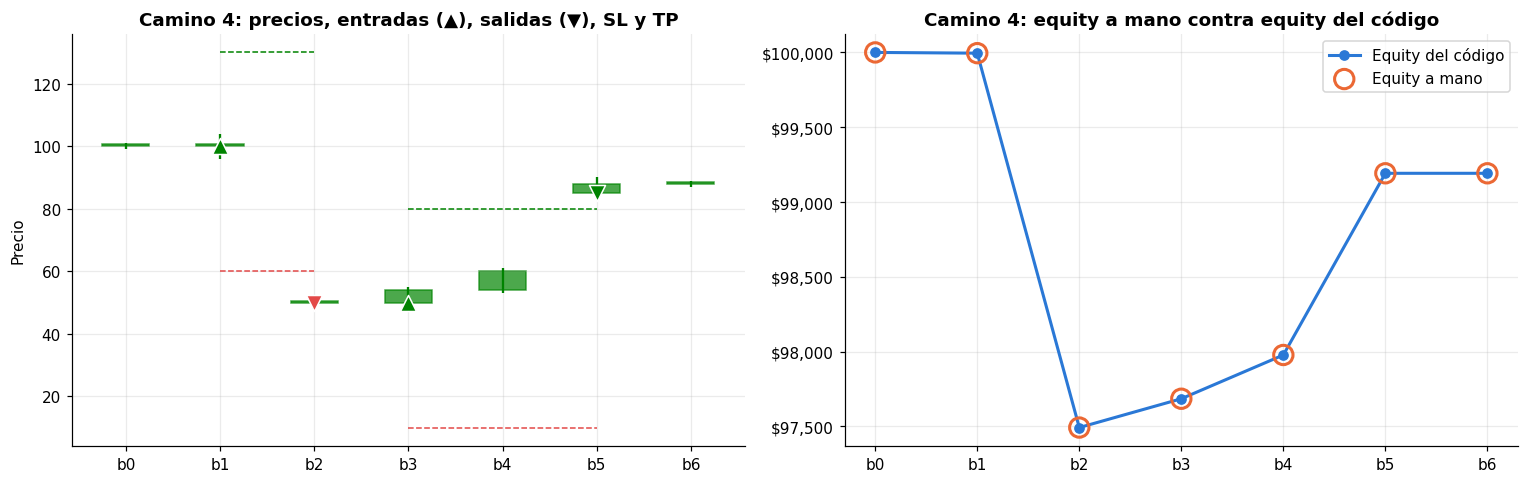

In [7]:
# Camino 4 barra por barra: equity a mano contra equity del código
rows4, prm4, _ = caminos["4. Dos operaciones: gaps, compuesto y break-even"]
b4 = make_bars(rows4); r4 = backtest(b4, prm4)
a_mano = [100_000.0, 99_995.0, 97_492.5, 97_685.0476875, 97_977.5251875, 99_192.03800625, 99_192.03800625]
comp4 = pd.DataFrame({"Equity a mano": a_mano, "Equity código": r4["equity"]["equity"].to_numpy(),
                      "Cash código": r4["equity"]["cash"].to_numpy(), "Unidades": r4["equity"]["units"].to_numpy()},
                     index=[f"b{i}" for i in range(len(a_mano))])
comp4["Diferencia"] = comp4["Equity código"] - comp4["Equity a mano"]
display(comp4)

fig, axs = plt.subplots(1, 2, figsize=(14, 4.5))
x = np.arange(len(b4))
for i, (o_, h_, l_, c_) in enumerate(b4[["open", "high", "low", "close"]].to_numpy()):
    colr = GOOD if c_ >= o_ else BAD
    axs[0].vlines(i, l_, h_, color=colr, lw=1.5)
    axs[0].add_patch(plt.Rectangle((i - 0.25, min(o_, c_)), 0.5, max(abs(c_ - o_), 0.6), color=colr, alpha=0.7))
t4 = r4["trades"]
for _, t in t4.iterrows():
    ie, ix = b4.index.get_loc(t["entrada"]), b4.index.get_loc(t["salida"])
    axs[0].scatter(ie, t["precio_entrada"], marker="^", s=110, color=GOOD, edgecolor="white", zorder=5)
    axs[0].scatter(ix, t["precio_salida"], marker="v", s=110, color=BAD if t["pnl"] < 0 else GOOD, edgecolor="white", zorder=5)
    axs[0].hlines([t["stop_inicial"], t["take_profit"]], ie, ix, colors=[BAD, GOOD], linestyles="--", lw=1)
axs[0].set_xticks(x, [f"b{i}" for i in x]); axs[0].set_title("Camino 4: precios, entradas (▲), salidas (▼), SL y TP")
axs[0].set_ylabel("Precio")
axs[1].plot(x, comp4["Equity código"], color=BLUE, lw=2, marker="o", label="Equity del código")
axs[1].scatter(x, comp4["Equity a mano"], s=160, facecolors="none", edgecolors=ORANGE, lw=2, label="Equity a mano", zorder=5)
axs[1].set_xticks(x, [f"b{i}" for i in x]); axs[1].yaxis.set_major_formatter(usd)
axs[1].set_title("Camino 4: equity a mano contra equity del código"); axs[1].legend()
plt.tight_layout(); plt.show()

## 5. Prueba de truncamiento del pipeline completo

Si en algún punto del pipeline se usara información del futuro, el valor en *t* cambiaría al quitar las barras posteriores. La prueba recalcula **todo** (indicadores → señales → combinación → backtest) sobre `df.iloc[:t+1]` y exige que el valor en *t* sea idéntico al de la corrida completa: indicadores, condiciones C1/C2, señal, disparador, cash, unidades y equity.

Primero los tres puntos de `test_pipeline_truncation` y después un barrido de 40 fechas repartidas en toda la muestra **más** la barra a la mitad de cada una de las 17 operaciones (para probar también el estado con posición abierta).

In [8]:
COLS = ["sma_10", "sma_100", "rsi_14", "macd", "macd_signal", "bb_mid", "bb_high", "atr_14",
        "c1_tendencia", "c2_momentum", "entry_signal", "entry_trigger"]
full = run_pipeline(df, P)

def trunc_check(t):
    part = run_pipeline(df.iloc[:t + 1], P)
    f = full["data"][COLS].iloc[t]; p = part["data"][COLS].iloc[-1]
    fe = full["equity"].iloc[t]; pe = part["equity"].iloc[-1]
    num = [c for c in COLS if c not in ("c1_tendencia", "c2_momentum", "entry_signal", "entry_trigger")]
    dif_ind = np.nanmax(np.abs(f[num].astype(float).to_numpy() - p[num].astype(float).to_numpy()))
    return {"t": t, "fecha": df.index[t],
            "máx |dif| indicadores": dif_ind,
            "señales iguales": bool((f[["c1_tendencia", "c2_momentum", "entry_signal", "entry_trigger"]] ==
                                     p[["c1_tendencia", "c2_momentum", "entry_signal", "entry_trigger"]]).all()),
            "equity completo": fe["equity"], "equity truncado": pe["equity"],
            "|dif| equity": abs(fe["equity"] - pe["equity"]),
            "en posición": bool(fe["en_posicion"])}

display(pd.DataFrame([trunc_check(t) for t in [800, 1800, 3000]]).set_index("t"))

,fecha,máx |dif| indicadores,señales iguales,equity completo,equity truncado,|dif| equity,en posición
t,,,,,,,
800,2022-10-12 08:00:00,0.00,True,"101,217.61","101,217.61",0.00,False
1800,2023-03-30 20:00:00,0.00,True,"104,599.34","104,599.34",0.00,False
3000,2023-10-17 04:00:00,0.00,True,"103,559.83","103,559.83",0.00,False


Fechas probadas: 57  |  de las cuales 18 con posición abierta
Máxima diferencia en indicadores: 0.00e+00
Máxima diferencia en equity:      0.00e+00
Señales idénticas en todas:       True


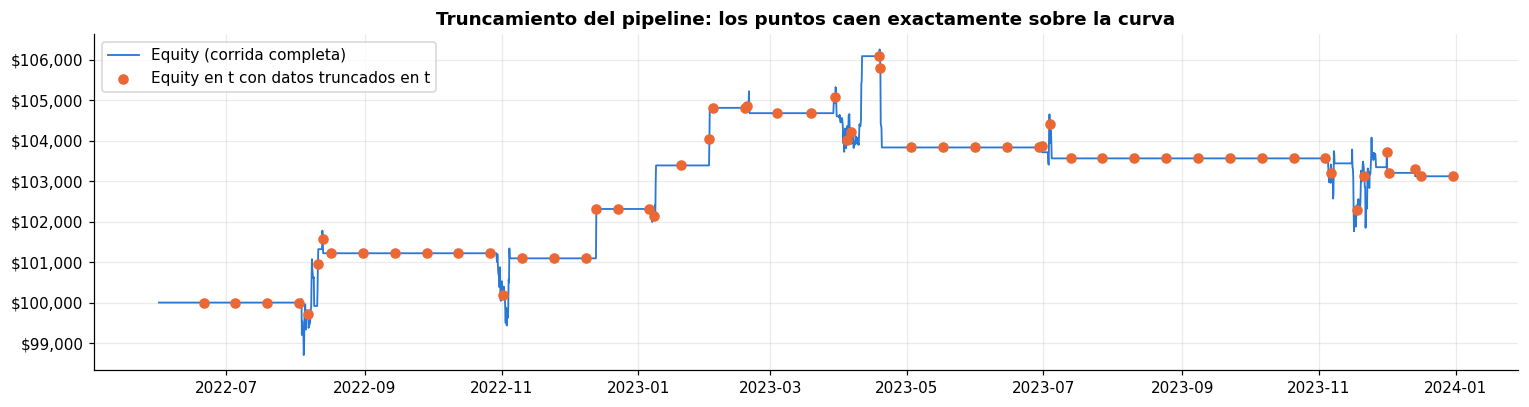

In [9]:
ts_rej = np.linspace(120, len(df) - 2, 40).astype(int)
ts_ops = [(df.index.get_loc(t["entrada"]) + df.index.get_loc(t["salida"])) // 2 for _, t in trades.iterrows()]
ts = np.unique(np.r_[ts_rej, ts_ops])   # 40 fechas repartidas + la barra a la mitad de cada operación
barrido = pd.DataFrame([trunc_check(t) for t in ts]).set_index("t")
print(f"Fechas probadas: {len(barrido)}  |  de las cuales {barrido['en posición'].sum()} con posición abierta")
print(f"Máxima diferencia en indicadores: {barrido['máx |dif| indicadores'].max():.2e}")
print(f"Máxima diferencia en equity:      {barrido['|dif| equity'].max():.2e}")
print(f"Señales idénticas en todas:       {barrido['señales iguales'].all()}")

fig, ax = plt.subplots(figsize=(14, 3.8))
ax.plot(full["equity"].index, full["equity"]["equity"], color=BLUE, lw=1.2, label="Equity (corrida completa)")
ax.scatter(barrido["fecha"], barrido["equity truncado"], color=ORANGE, s=35, zorder=5, label="Equity en t con datos truncados en t")
ax.yaxis.set_major_formatter(usd); ax.set_title("Truncamiento del pipeline: los puntos caen exactamente sobre la curva")
ax.legend(loc="upper left"); plt.tight_layout(); plt.show()

## 6. Suite de pruebas (`tests/test_strategy.py`)
Incluye las pruebas de la Act 05 y las nuevas de la Act 06: los golden-file de stop-loss con slippage y de dos operaciones, la pureza de `backtest()`, la mezcla de costos de la curva de sensibilidad, el drawdown máximo calculado a mano, las fórmulas de p\* y el truncamiento del pipeline (que ahora también compara las operaciones cerradas hasta *t*).

In [10]:
out = subprocess.run([sys.executable, "-m", "pytest", "-v", "--color=no", "-p", "no:cacheprovider", "tests"],
                     capture_output=True, text=True)
print(out.stdout[out.stdout.find("collected"):][-3500:])

collected 18 items

tests/test_strategy.py::test_same_bar_stop_and_target_closes_as_stop PASSED [  5%]
tests/test_strategy.py::test_sizing_returns_exact_risk_budget[100000-30000-29500-0.02] PASSED [ 11%]
tests/test_strategy.py::test_sizing_returns_exact_risk_budget[100000-100-85-0.02] PASSED [ 16%]
tests/test_strategy.py::test_sizing_returns_exact_risk_budget[57321.4-42310.0-42014.87-0.01] PASSED [ 22%]
tests/test_strategy.py::test_never_two_open_positions PASSED             [ 27%]
tests/test_strategy.py::test_default_atr_stop_multiplier_is_four PASSED  [ 33%]
tests/test_strategy.py::test_entry_trigger_requires_macd_upward_crossover PASSED [ 38%]
tests/test_strategy.py::test_golden_take_profit PASSED                   [ 44%]
tests/test_strategy.py::test_golden_break_even PASSED                    [ 50%]
tests/test_strategy.py::test_golden_stop_loss_with_slippage PASSED       [ 55%]
tests/test_strategy.py::test_golden_two_trades_gaps_and_compounding PASSED [ 61%]
tests/test_strategy.py:

## 7. Resultados del backtest: lista de operaciones

In [11]:
cols = ["entrada", "salida", "precio_entrada", "precio_salida", "stop_inicial", "take_profit",
        "unidades", "nocional", "costos", "pnl", "retorno_%", "R", "motivo", "barras"]
tabla_ops = trades[cols].copy()
tabla_ops.index = range(1, len(tabla_ops) + 1); tabla_ops.index.name = "Operación"
tabla_ops.to_csv("operaciones.csv")
print(f"{len(tabla_ops)} operaciones cerradas (guardadas en operaciones.csv).  Posición abierta al final: "
      f"{'sí' if res['open_position'] else 'ninguna'}")
tabla_ops.style.format({"precio_entrada": "{:,.2f}", "precio_salida": "{:,.2f}", "stop_inicial": "{:,.2f}",
                        "take_profit": "{:,.2f}", "unidades": "{:.4f}", "nocional": "${:,.0f}", "costos": "${:,.2f}",
                        "pnl": "${:,.2f}", "retorno_%": "{:+.2f}%", "R": "{:+.3f}"}) \
    .map(lambda v: f"color: {GOOD}" if isinstance(v, (int, float)) and v > 0 else (f"color: {BAD}" if isinstance(v, (int, float)) and v < 0 else ""),
         subset=["pnl", "R"])

17 operaciones cerradas (guardadas en operaciones.csv).  Posición abierta al final: ninguna


,entrada,salida,precio_entrada,precio_salida,stop_inicial,take_profit,unidades,nocional,costos,pnl,retorno_%,R,motivo,barras
Operación,,,,,,,,,,,,,,
1,2022-08-03 16:00:00,2022-08-09 08:00:00,"23,378.78","23,367.09","21,983.96","24,424.90",1.4339,"$33,522",$67.03,$-83.79,-0.25%,-0.042,break_even,35
2,2022-08-10 20:00:00,2022-08-11 04:00:00,"23,650.07","24,576.99","22,397.78","24,589.28",1.5957,"$37,739",$76.96,"$1,402.17",+3.72%,+0.702,take_profit,3
3,2022-08-13 00:00:00,2022-08-13 08:00:00,"24,414.39","24,402.18","23,187.28","25,334.72",1.6513,"$40,316",$80.61,$-100.77,-0.25%,-0.050,break_even,3
4,2022-10-29 20:00:00,2022-11-04 16:00:00,"20,851.72","20,841.29","20,011.29","21,482.04",2.4087,"$50,226",$100.43,$-125.54,-0.25%,-0.062,break_even,36
5,2022-12-13 08:00:00,2022-12-13 08:00:00,"17,173.04","17,414.84","16,839.01","17,423.55",5.8808,"$100,991",$203.40,"$1,218.62",+1.21%,+0.620,take_profit,1
6,2023-01-07 00:00:00,2023-01-09 00:00:00,"16,960.59","17,173.13","16,665.76","17,181.72",6.0262,"$102,208",$205.70,"$1,075.10",+1.05%,+0.605,take_profit,13
7,2023-02-01 20:00:00,2023-02-02 00:00:00,"23,400.80","24,097.11","22,456.30","24,109.17",2.1892,"$51,230",$103.98,"$1,420.41",+2.77%,+0.687,take_profit,2
8,2023-02-18 00:00:00,2023-02-19 20:00:00,"24,577.58","24,526.82","22,969.47","25,783.66",1.3035,"$32,036",$64.01,$-130.17,-0.41%,-0.062,break_even,12
9,2023-03-29 08:00:00,2023-03-30 16:00:00,"28,099.68","28,085.63","26,182.40","29,537.65",1.0919,"$30,683",$61.35,$-76.69,-0.25%,-0.037,break_even,9


,Operaciones,PnL_total,PnL_promedio,R_promedio,Holding_prom_barras,Costos,% de operaciones
motivo,,,,,,,
take_profit,5,"6,600.42","1,320.08",0.66,16.20,657.62,29.41
break_even,11,"-1,228.32",-111.67,-0.05,17.64,942.49,64.71
stop_loss,1,"-2,253.77","-2,253.77",-1.06,8.00,106.10,5.88


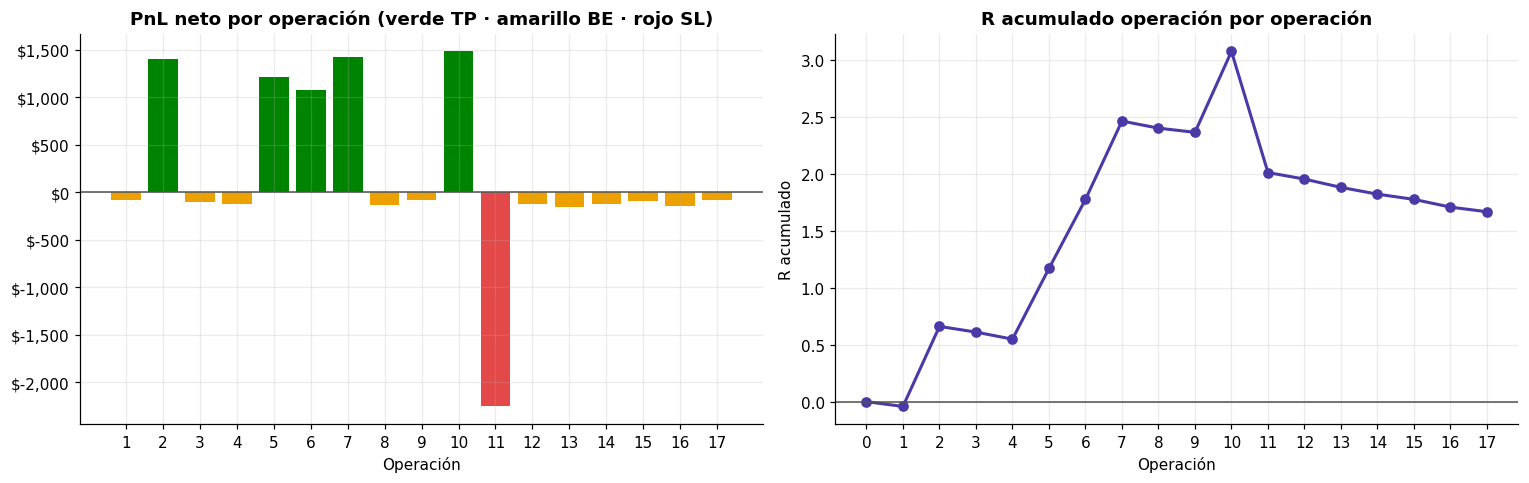

In [12]:
por_motivo = trades.groupby("motivo").agg(Operaciones=("pnl", "size"), PnL_total=("pnl", "sum"),
                                           PnL_promedio=("pnl", "mean"), R_promedio=("R", "mean"),
                                           Holding_prom_barras=("barras", "mean"), Costos=("costos", "sum"))
por_motivo["% de operaciones"] = 100 * por_motivo["Operaciones"] / len(trades)
display(por_motivo.reindex(["take_profit", "break_even", "stop_loss"]))

fig, axs = plt.subplots(1, 2, figsize=(14, 4.5))
colores = trades["motivo"].map({"take_profit": GOOD, "break_even": WARN, "stop_loss": BAD})
axs[0].bar(range(1, len(trades) + 1), trades["pnl"], color=colores)
axs[0].axhline(0, color="#52514e", lw=1); axs[0].yaxis.set_major_formatter(usd)
axs[0].set_title("PnL neto por operación (verde TP · amarillo BE · rojo SL)"); axs[0].set_xlabel("Operación")
axs[0].set_xticks(range(1, len(trades) + 1))
axs[1].plot(range(0, len(trades) + 1), np.r_[0, trades["R"].cumsum()], color=VIOLET, lw=2, marker="o")
axs[1].axhline(0, color="#52514e", lw=1)
axs[1].set_title("R acumulado operación por operación"); axs[1].set_xlabel("Operación"); axs[1].set_ylabel("R acumulado")
axs[1].set_xticks(range(0, len(trades) + 1))
plt.tight_layout(); plt.show()

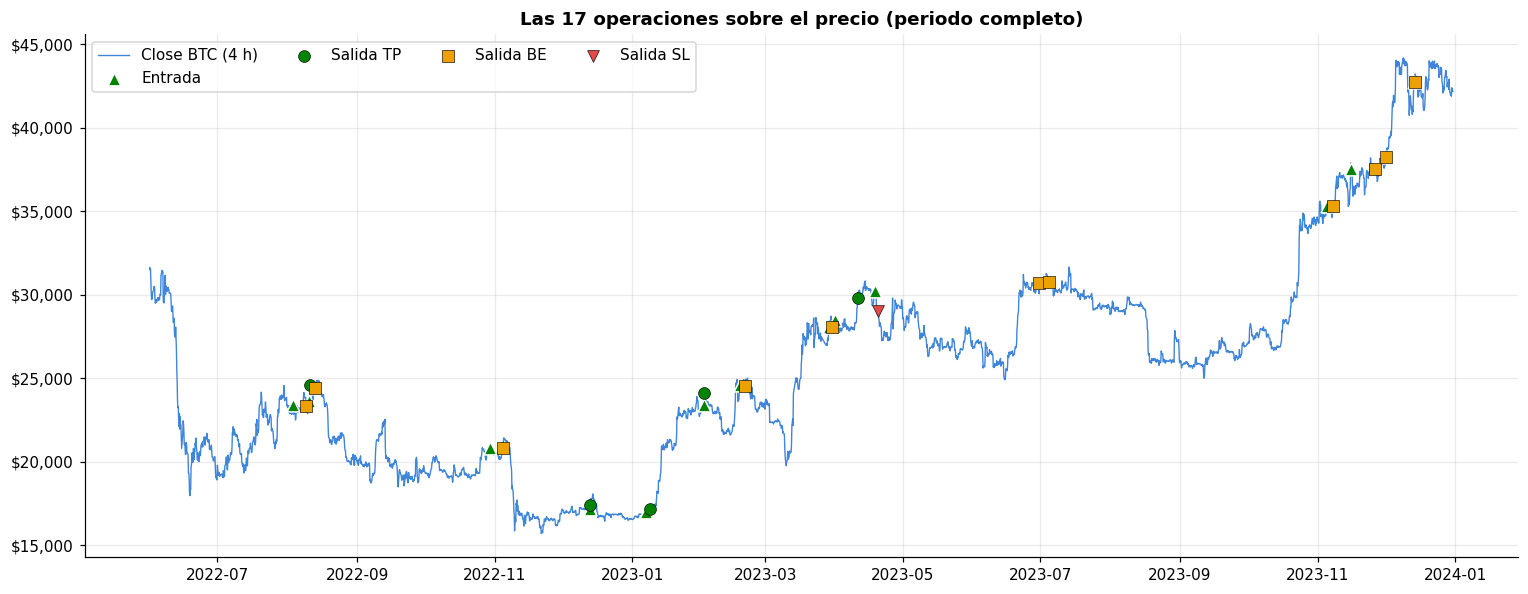

In [13]:
fig, ax = plt.subplots(figsize=(14, 5.5))
ax.plot(data.index, data["close"], color=BLUE, lw=0.9, alpha=0.9, label="Close BTC (4 h)")
ax.scatter(trades["entrada"], trades["precio_entrada"], marker="^", s=70, color=GOOD, edgecolor="white", zorder=5, label="Entrada")
for motivo, (mk, colr, lab) in {"take_profit": ("o", GOOD, "Salida TP"), "break_even": ("s", WARN, "Salida BE"),
                               "stop_loss": ("v", BAD, "Salida SL")}.items():
    s = trades[trades["motivo"] == motivo]
    ax.scatter(s["salida"], s["precio_salida"], marker=mk, s=60, color=colr, edgecolor="black", lw=0.4, zorder=6, label=lab)
ax.yaxis.set_major_formatter(usd); ax.set_title("Las 17 operaciones sobre el precio (periodo completo)")
ax.legend(loc="upper left", ncol=4); plt.tight_layout(); plt.show()

## 8. Curva de equity y curva de drawdown

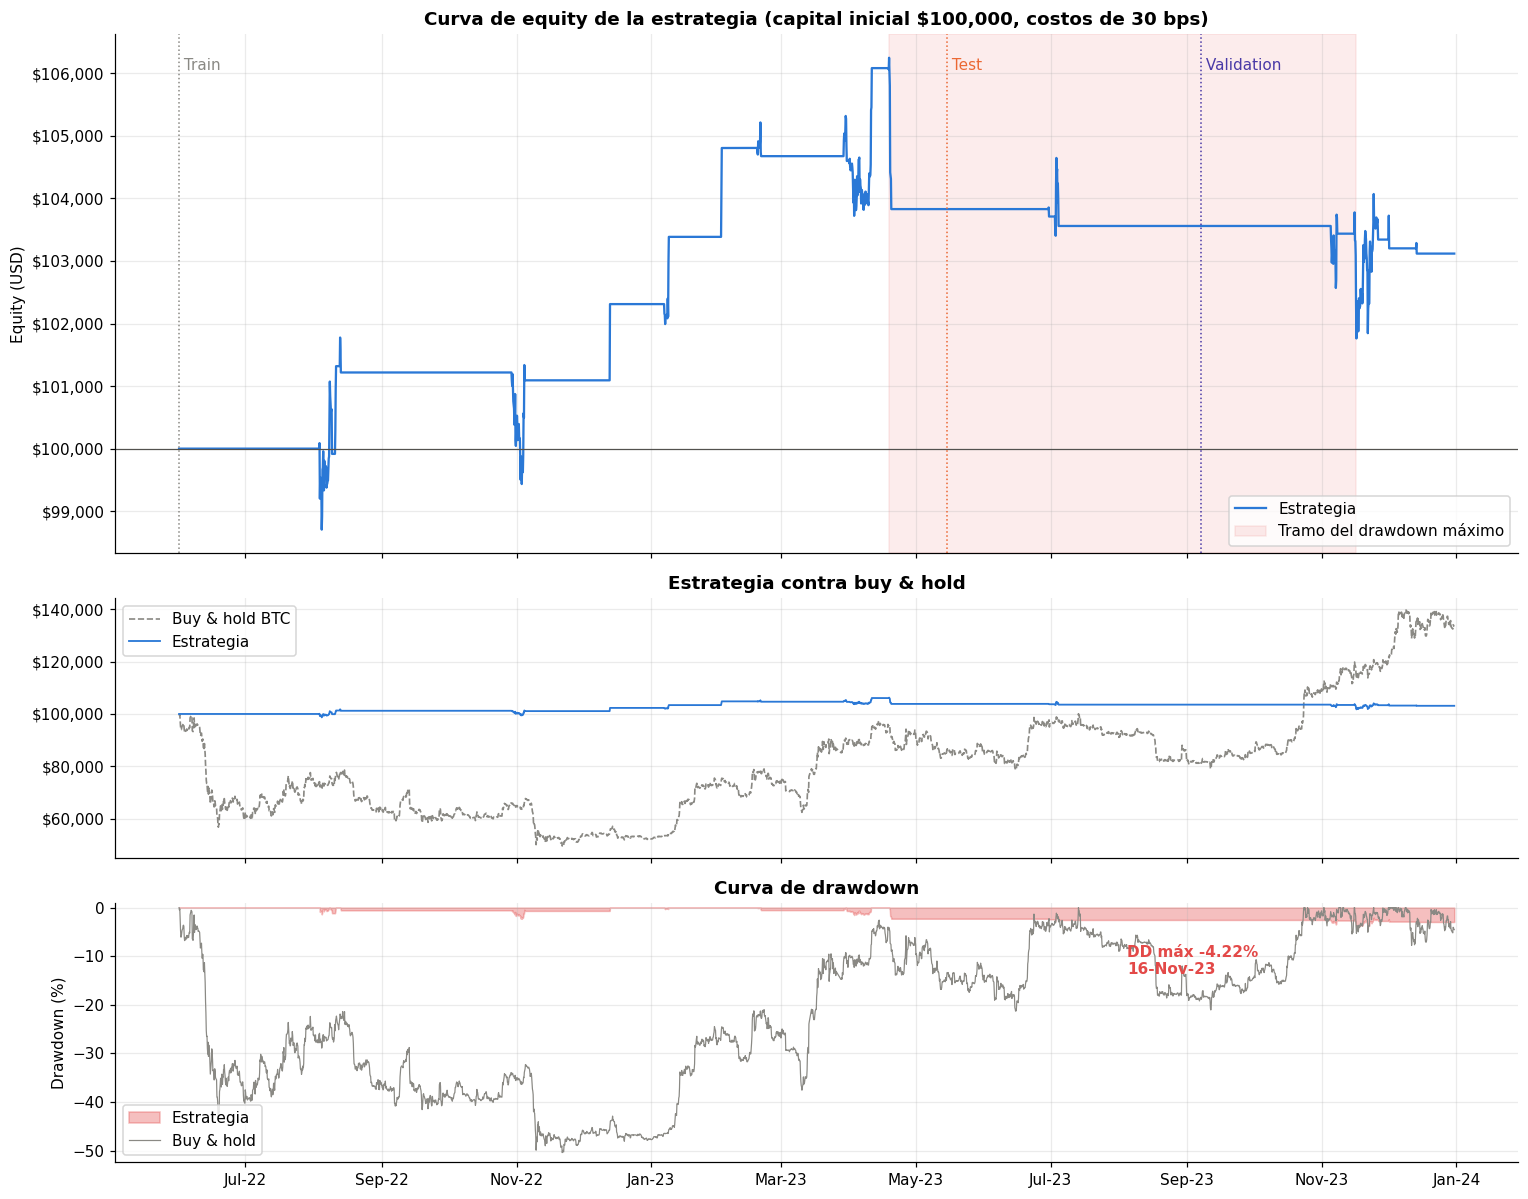

Drawdown máximo estrategia: -4.22% (pico 18-Apr-2023 -> valle 16-Nov-2023)  |  buy & hold: -50.38%


In [14]:
bh = P.initial_cash * data["close"] / data["close"].iloc[0]
dd = M.drawdown(eq["equity"]); dd_bh = M.drawdown(bh)
t_mdd = dd.idxmin(); t_pico = eq["equity"].loc[:t_mdd].idxmax()

fig, axs = plt.subplots(3, 1, figsize=(14, 11), sharex=True, gridspec_kw={"height_ratios": [2, 1, 1]})
axs[0].plot(eq.index, eq["equity"], color=BLUE, lw=1.5, label="Estrategia")
axs[0].axhline(P.initial_cash, color="#52514e", lw=0.8)
axs[0].axvspan(t_pico, t_mdd, color=BAD, alpha=0.1, label="Tramo del drawdown máximo")
for (k, v), c in zip(splits.items(), [GRAY, ORANGE, VIOLET]):
    axs[0].axvline(v.index[0], color=c, ls=":", lw=1); axs[0].text(v.index[0], eq["equity"].max(), f" {k}", color=c, va="top")
axs[0].yaxis.set_major_formatter(usd); axs[0].legend(loc="lower right"); axs[0].set_ylabel("Equity (USD)")
axs[0].set_title("Curva de equity de la estrategia (capital inicial $100,000, costos de 30 bps)")
axs[1].plot(bh.index, bh, color=GRAY, lw=1.1, ls="--", label="Buy & hold BTC")
axs[1].plot(eq.index, eq["equity"], color=BLUE, lw=1.2, label="Estrategia")
axs[1].yaxis.set_major_formatter(usd); axs[1].legend(loc="upper left"); axs[1].set_title("Estrategia contra buy & hold")
axs[2].fill_between(dd.index, 100 * dd, 0, color=BAD, alpha=0.35, label="Estrategia")
axs[2].plot(dd_bh.index, 100 * dd_bh, color=GRAY, lw=0.8, label="Buy & hold")
axs[2].annotate(f"DD máx {100*dd.min():.2f}%\n{t_mdd:%d-%b-%y}", xy=(t_mdd, 100 * dd.min()), xytext=(-150, -30),
                textcoords="offset points", color=BAD, fontweight="bold")
axs[2].set_ylim(max(100 * dd_bh.min(), -60) - 2, 1)
axs[2].set_title("Curva de drawdown"); axs[2].set_ylabel("Drawdown (%)"); axs[2].legend(loc="lower left")
axs[2].xaxis.set_major_formatter(mdates.DateFormatter("%b-%y"))
plt.tight_layout(); plt.show()
print(f"Drawdown máximo estrategia: {100*dd.min():.2f}% (pico {t_pico:%d-%b-%Y} -> valle {t_mdd:%d-%b-%Y})  |  "
      f"buy & hold: {100*dd_bh.min():.2f}%")

## 9. Métricas de desempeño (`src/metrics.py`)
Nuevas en esta sesión: **p\* con payoff empírico** y **expectancy en R** (se suman al drawdown máximo, Calmar, turnover y win rate que ya existían).

In [15]:
resumen = M.summary(res)
display(resumen.to_frame("Periodo completo"))

,Periodo completo
Capital inicial ($),"100,000.00"
Capital final ($),"103,118.33"
Ganancia/Pérdida ($),"3,118.33"
Rendimiento total (%),3.12
Rendimiento anualizado CAGR (%),1.96
Volatilidad anualizada (%),4.08
Sharpe (anualizado),0.50
Drawdown máximo (%),-4.22
Calmar,0.46
Operaciones cerradas,17


### 9.1 Por tramo (train / test / validation)
Cada tramo corre por separado con $100,000; los indicadores se calculan dentro de cada tramo (las primeras ~100 barras de cada tramo son calentamiento).

In [16]:
por_tramo = {"Completo": resumen}
for k, v in splits.items():
    por_tramo[k] = M.summary(run_pipeline(v, P))
tabla_tramos = pd.DataFrame(por_tramo).loc[["Capital final ($)", "Rendimiento total (%)", "Rendimiento anualizado CAGR (%)",
    "Sharpe (anualizado)", "Drawdown máximo (%)", "Calmar", "Operaciones cerradas", "Win rate empírico (%)",
    "Expectancy (R por operación)", "Turnover anual (x equity)", "Costos totales ($)", "Veredicto (Calmar)"]]
tabla_tramos

,Completo,Train,Test,Validation
Capital final ($),"103,118.33","103,829.69","99,740.09","99,573.67"
Rendimiento total (%),3.12,3.83,-0.26,-0.43
Rendimiento anualizado CAGR (%),1.96,4.02,-0.82,-1.35
Sharpe (anualizado),0.50,0.95,-0.37,-0.26
Drawdown máximo (%),-4.22,-2.30,-1.04,-1.94
Calmar,0.46,1.75,-0.79,-0.69
Operaciones cerradas,17,11,2,4
Win rate empírico (%),29.41,45.45,0.00,0.00
Expectancy (R por operación),0.10,0.18,-0.07,-0.05
Turnover anual (x equity),10.50,11.69,6.62,10.87


## 10. Sensibilidad a costos: 0 a 50 bps de ida y vuelta

Se barre el costo total de ida y vuelta manteniendo la mezcla del SPEC (2/3 comisión, 1/3 slippage) con `scale_costs()`. Así el punto de 30 bps coincide exactamente con el backtest base (10 + 5 bps por lado).

> En la Act 05 se usaba `with_costs()`, que pone todo como comisión y deja el slippage en 0; por eso ahí el punto de 30 bps daba $102,710 y no $103,118. La diferencia viene de que el slippage mueve el precio de llenado (y con él SL y TP), mientras que la comisión no.

In [17]:
sens = []
for bps in range(0, 55, 5):
    r = backtest(data, scale_costs(P, bps)); e = r["equity"]["equity"]
    sens.append({"Costo ida y vuelta (bps)": bps, "Capital final ($)": e.iloc[-1], "Rendimiento (%)": 100 * (e.iloc[-1] / P.initial_cash - 1),
                 "Sharpe": M.sharpe(e), "Calmar": M.calmar(e), "Drawdown máx (%)": 100 * M.max_drawdown(e),
                 "Costos pagados ($)": r["trades"]["costos"].sum(), "Veredicto": M.viability(M.calmar(e))})
sens = pd.DataFrame(sens).set_index("Costo ida y vuelta (bps)")
display(sens)

# costo de equilibrio: dónde el capital final regresa a $100,000
grid = np.arange(0, 205, 5)
finales = np.array([backtest(data, scale_costs(P, g))["equity"]["equity"].iloc[-1] for g in grid])
cruce = np.interp(0, (finales - P.initial_cash)[::-1], grid[::-1]) if (finales < P.initial_cash).any() else np.nan
sh = np.array([M.sharpe(backtest(data, scale_costs(P, g))["equity"]["equity"]) for g in grid[:21]])
print(f"Costo de equilibrio (capital final = $100,000): ≈ {cruce:.0f} bps de ida y vuelta")
print(f"Cada 10 bps extra cuestan ≈ ${-(sens['Capital final ($)'].diff().mean())*2:,.0f} de capital final y "
      f"≈ {-(sens['Sharpe'].diff().mean())*2:.2f} de Sharpe")

,Capital final ($),Rendimiento (%),Sharpe,Calmar,Drawdown máx (%),Costos pagados ($),Veredicto
Costo ida y vuelta (bps),,,,,,,
0,"105,294.06",5.29,0.81,0.88,-3.76,0.00,MARGINAL
5,"104,928.47",4.93,0.76,0.80,-3.84,286.73,MARGINAL
10,"104,564.08",4.56,0.71,0.73,-3.91,572.51,MARGINAL
15,"104,200.87",4.20,0.66,0.66,-3.99,857.34,MARGINAL
20,"103,838.84",3.84,0.60,0.59,-4.07,"1,141.23",MARGINAL
25,"103,477.99",3.48,0.55,0.53,-4.15,"1,424.19",MARGINAL
30,"103,118.33",3.12,0.50,0.46,-4.22,"1,706.21",NO VIABLE
35,"102,759.83",2.76,0.44,0.40,-4.30,"1,987.29",NO VIABLE
40,"102,402.50",2.40,0.39,0.35,-4.38,"2,267.45",NO VIABLE


Costo de equilibrio (capital final = $100,000): ≈ 74 bps de ida y vuelta
Cada 10 bps extra cuestan ≈ $721 de capital final y ≈ 0.11 de Sharpe


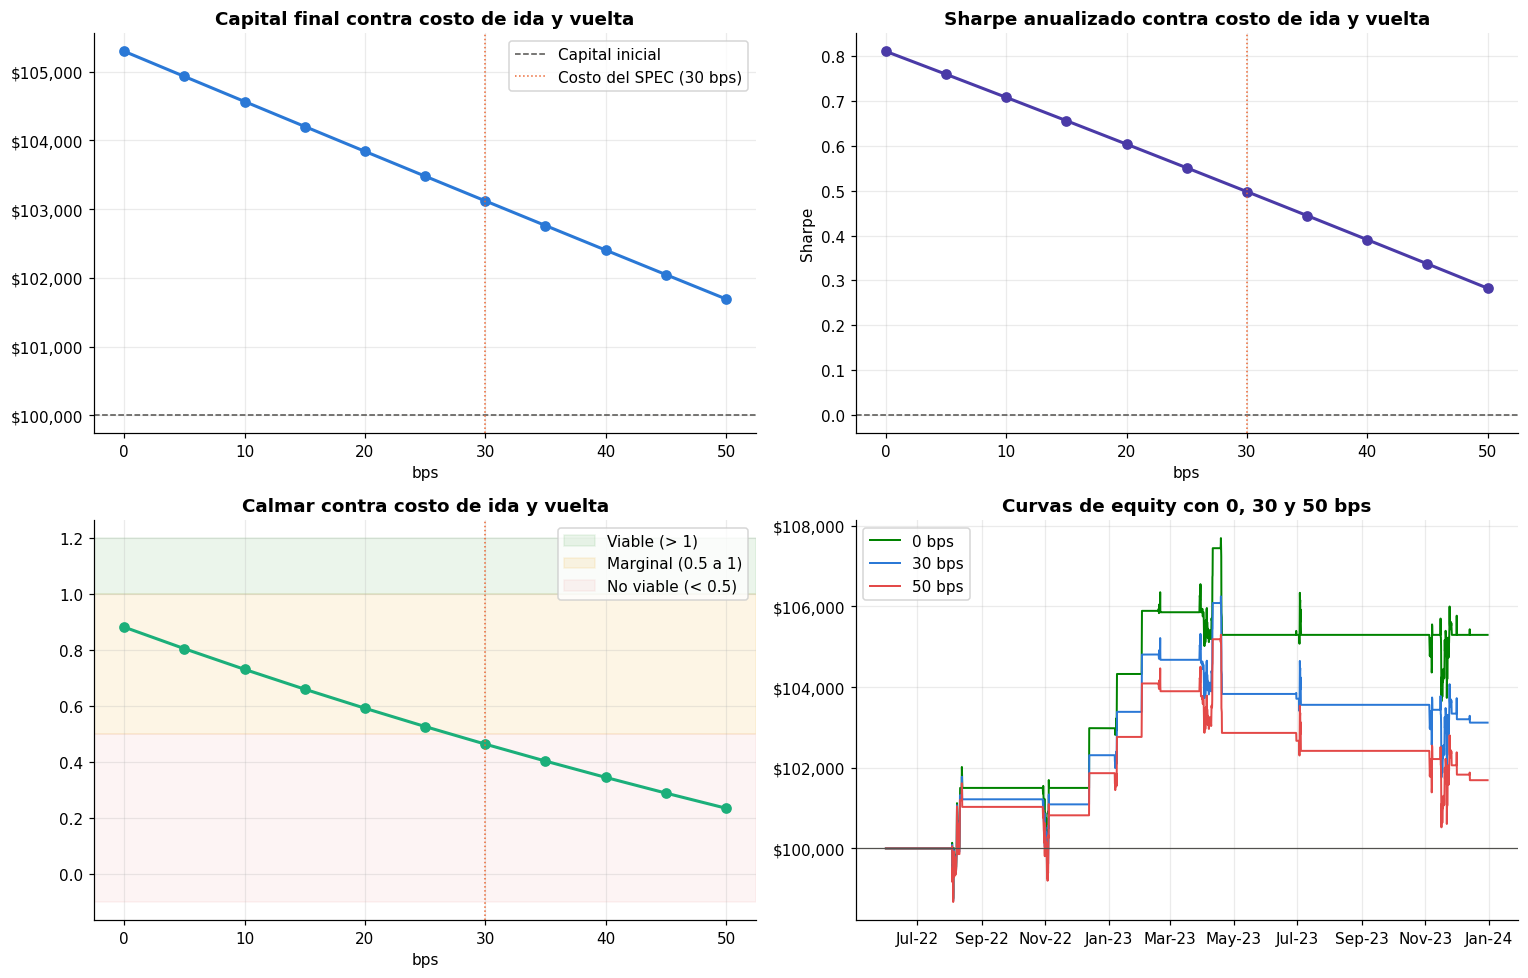

In [18]:
fig, axs = plt.subplots(2, 2, figsize=(14, 9))
ax = axs[0, 0]
ax.plot(sens.index, sens["Capital final ($)"], color=BLUE, lw=2, marker="o")
ax.axhline(P.initial_cash, color="#52514e", lw=1, ls="--", label="Capital inicial")
ax.axvline(30, color=ORANGE, lw=1, ls=":", label="Costo del SPEC (30 bps)")
ax.set_title("Capital final contra costo de ida y vuelta"); ax.set_xlabel("bps"); ax.yaxis.set_major_formatter(usd); ax.legend()
ax = axs[0, 1]
ax.plot(sens.index, sens["Sharpe"], color=VIOLET, lw=2, marker="o")
ax.axhline(0, color="#52514e", lw=1, ls="--"); ax.axvline(30, color=ORANGE, lw=1, ls=":")
ax.set_title("Sharpe anualizado contra costo de ida y vuelta"); ax.set_xlabel("bps"); ax.set_ylabel("Sharpe")
ax = axs[1, 0]
ax.plot(sens.index, sens["Calmar"], color=AQUA, lw=2, marker="o")
ax.axhspan(1, max(1.2, sens["Calmar"].max() + 0.1), color=GOOD, alpha=0.08, label="Viable (> 1)")
ax.axhspan(0.5, 1, color=WARN, alpha=0.10, label="Marginal (0.5 a 1)")
ax.axhspan(min(0, sens["Calmar"].min()) - 0.1, 0.5, color=BAD, alpha=0.06, label="No viable (< 0.5)")
ax.axvline(30, color=ORANGE, lw=1, ls=":")
ax.set_title("Calmar contra costo de ida y vuelta"); ax.set_xlabel("bps"); ax.legend(loc="upper right")
ax = axs[1, 1]
for bps_, colr in [(0, GOOD), (30, BLUE), (50, BAD)]:
    e = backtest(data, scale_costs(P, bps_))["equity"]["equity"]
    ax.plot(e.index, e, color=colr, lw=1.3, label=f"{bps_} bps")
ax.axhline(P.initial_cash, color="#52514e", lw=0.8); ax.yaxis.set_major_formatter(usd)
ax.set_title("Curvas de equity con 0, 30 y 50 bps"); ax.legend(loc="upper left")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b-%y"))
plt.tight_layout(); plt.show()

### 10.1 Turnover y arrastre de costos
El turnover conecta la frecuencia de operación con el costo: arrastre anual ≈ turnover × costo por lado. Si la cuenta cuadra con la diferencia de CAGR entre 0 y 30 bps, el motor está cobrando los costos donde debe.

In [19]:
s0 = M.summary(backtest(data, scale_costs(P, 0)))
arrastre_teo = resumen["Turnover anual (x equity)"] * 0.0015
arrastre_obs = (s0["Rendimiento anualizado CAGR (%)"] - resumen["Rendimiento anualizado CAGR (%)"]) / 100
pd.DataFrame({"Valor": {
    "Turnover anual (x equity promedio)": resumen["Turnover anual (x equity)"],
    "Costo por lado (bps)": 15.0,
    "Arrastre anual estimado = turnover × 15 bps (%)": 100 * arrastre_teo,
    "CAGR sin costos (%)": s0["Rendimiento anualizado CAGR (%)"],
    "CAGR con 30 bps (%)": resumen["Rendimiento anualizado CAGR (%)"],
    "Arrastre anual observado (%)": 100 * arrastre_obs}})

,Valor
Turnover anual (x equity promedio),10.50
Costo por lado (bps),15.00
Arrastre anual estimado = turnover × 15 bps (%),1.57
CAGR sin costos (%),3.31
CAGR con 30 bps (%),1.96
Arrastre anual observado (%),1.35


## 11. Win rate teórico (p\*) contra empírico

El SPEC define p\* = 1 / (1 + R) con R = TP / SL. Con los parámetros vigentes **R = 3 / 4 = 0.75**, así que p\* = 57.1 % sin costos. Con costos, p\*_c = (1 + c) / (1 + R), donde c es el costo de ida y vuelta medido en unidades de riesgo.

Esa fórmula supone que **toda pérdida es −1 R**. Con el break-even eso no pasa: la mayoría de las pérdidas son de ≈ −0.05 R (solo comisión). Por eso se agrega un tercer umbral con el payoff real de las operaciones: p\*_payoff = |pérdida media| / (ganancia media + |pérdida media|).

R = TP/SL = 3.0/4.0 = 0.75  |  riesgo típico = 4.28% del precio  ->  30 bps = 0.070 R


,Valor (%)
p* teórico sin costos = 1/(1+R),57.14
p* teórico con costos = (1+c)/(1+R),61.15
p* con payoff empírico = |L|/(W+|L|),18.02
Win rate empírico (PnL neto > 0),29.41
% de operaciones que tocan el TP,29.41


Expectancy = +0.098 R por operación  (error estándar 0.109 R, t = 0.90, n = 17)


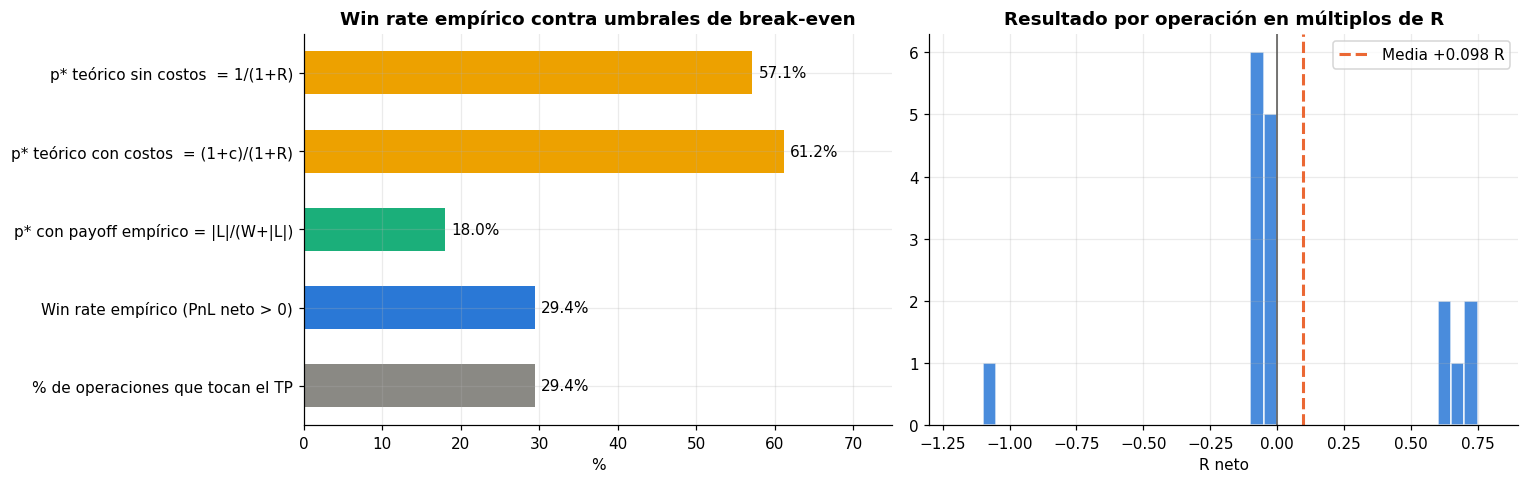

In [20]:
riesgo_pct = (P.sl_atr * data["atr_14"] / data["close"]).median()
c_R = 0.0030 / riesgo_pct
wr = M.winrate_table(trades, P, c_R)
print(f"R = TP/SL = {P.tp_atr}/{P.sl_atr} = {P.reward_risk:.2f}  |  riesgo típico = {100*riesgo_pct:.2f}% del precio  "
      f"->  30 bps = {c_R:.3f} R")
display(wr)

R = trades["R"]; se = R.std(ddof=1) / np.sqrt(len(R))
print(f"Expectancy = {R.mean():+.3f} R por operación  (error estándar {se:.3f} R, t = {R.mean()/se:.2f}, n = {len(R)})")

fig, axs = plt.subplots(1, 2, figsize=(14, 4.5))
etiquetas = wr.index[::-1]; valores = wr["Valor (%)"][::-1]
axs[0].barh(etiquetas, valores, color=[GRAY, BLUE, AQUA, WARN, WARN], height=0.55)
for i, v in enumerate(valores): axs[0].text(v + 0.8, i, f"{v:.1f}%", va="center")
axs[0].set_xlim(0, 75); axs[0].set_title("Win rate empírico contra umbrales de break-even"); axs[0].set_xlabel("%")
axs[1].hist(R, bins=np.arange(-1.2, 0.85, 0.05), color=BLUE, alpha=0.85, edgecolor="white")
axs[1].axvline(0, color="#52514e", lw=1); axs[1].axvline(R.mean(), color=ORANGE, lw=2, ls="--", label=f"Media {R.mean():+.3f} R")
axs[1].set_title("Resultado por operación en múltiplos de R"); axs[1].set_xlabel("R neto"); axs[1].legend()
plt.tight_layout(); plt.show()

## 12. Auditoría de sesgos

Antes de llenar la tabla se calcula la evidencia: huecos de datos, empates intrabar, salidas por gap y la robustez de los parámetros de salida.

In [21]:
raw = pd.read_csv(DATA, usecols=["Datetime", "Close"]); raw["Datetime"] = pd.to_datetime(raw["Datetime"])
limpio = raw.dropna()
huecos = limpio["Datetime"].diff()
velas_5m = limpio.set_index("Datetime")["Close"].resample("4h").count()

empates = gaps = 0
for _, t in trades.iterrows():
    bar = data.loc[t["salida"]]
    stop = t["precio_entrada"] if t["motivo"] == "break_even" else t["stop_inicial"]
    empates += int(bar["low"] <= stop and bar["high"] >= t["take_profit"])
    gaps += int(t["motivo"] != "take_profit" and bar["open"] <= stop and t["entrada"] != t["salida"])

evid = pd.DataFrame({"Valor": {
    "Filas de 5 min con NaN eliminadas": int(raw["Close"].isna().sum()),
    "Hueco más largo entre velas de 5 min": str(huecos.max()),
    "Huecos mayores a 1 hora": int((huecos > pd.Timedelta("1h")).sum()),
    "Bloques de 4 h sin ningún dato (se eliminan)": int((velas_5m == 0).sum()),
    "Barras de 4 h con menos de la mitad de sus 48 velas": int(((velas_5m > 0) & (velas_5m < 24)).sum()),
    "Empates intrabar SL/TP en las salidas": empates,
    "Salidas por gap (al open, bajo el stop)": gaps,
    f"Máx. diferencia en la prueba de truncamiento ({len(barrido)} fechas)": f"{max(barrido['máx |dif| indicadores'].max(), barrido['|dif| equity'].max()):.1e}",
}})
evid

,Valor
Filas de 5 min con NaN eliminadas,3745
Hueco más largo entre velas de 5 min,2 days 00:05:00
Huecos mayores a 1 hora,131
Bloques de 4 h sin ningún dato (se eliminan),19
Barras de 4 h con menos de la mitad de sus 48 velas,39
Empates intrabar SL/TP en las salidas,0
"Salidas por gap (al open, bajo el stop)",1
Máx. diferencia en la prueba de truncamiento (57 fechas),0.0e+00


### 12.1 Robustez de los parámetros de salida (evidencia de overfitting)
El SL pasó de 1.5 a 4 ATR después de ver resultados. Si 4 ATR fuera un pico aislado sería señal fuerte de sobreajuste; si la zona alrededor también funciona, el resultado es más creíble. Se evalúa una malla SL × TP sobre el periodo completo con costos de 30 bps.

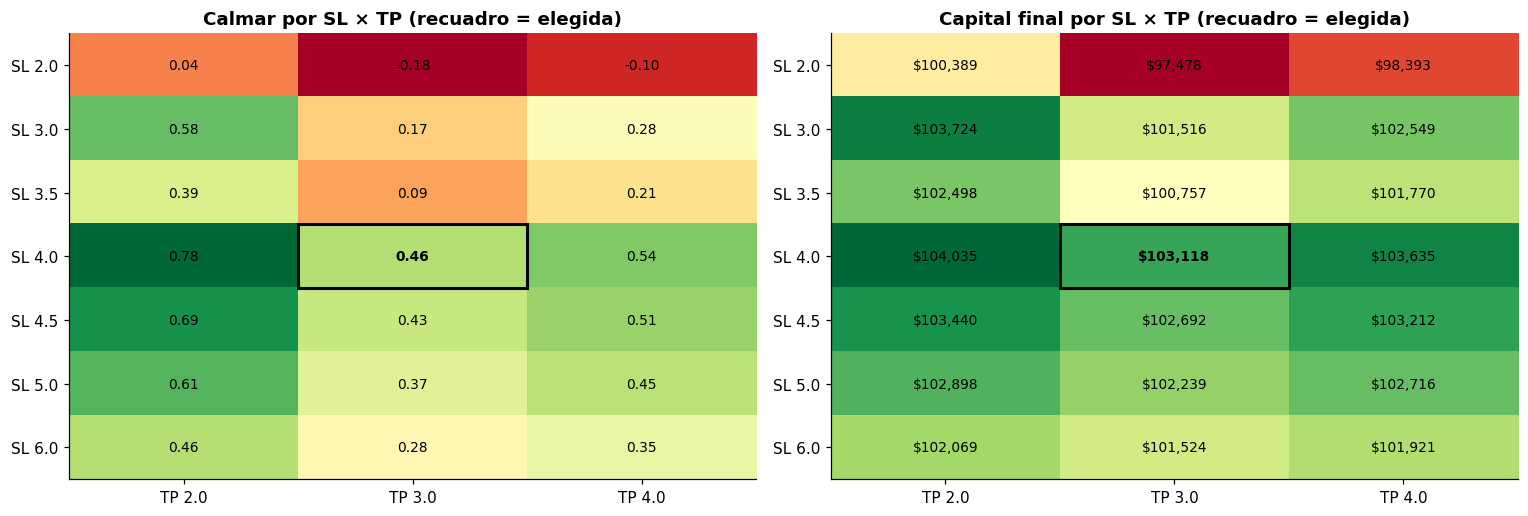

La configuración elegida (SL 4.0, TP 3.0) queda en el lugar 7 de 21 por Calmar.
El renglón con mejor Calmar promedio es SL = 4.0 ATR (el elegido).
Calmar máximo con SL = 2 ATR: 0.04  |  combinaciones con SL >= 3 que ganan dinero: 18 de 18


In [22]:
sl_grid, tp_grid = [2.0, 3.0, 3.5, 4.0, 4.5, 5.0, 6.0], [2.0, 3.0, 4.0]
malla_cal = pd.DataFrame(index=sl_grid, columns=tp_grid, dtype=float)
malla_cap = malla_cal.copy()
for sl in sl_grid:
    for tp in tp_grid:
        e = backtest(data, replace(P, sl_atr=sl, tp_atr=tp))["equity"]["equity"]
        malla_cal.loc[sl, tp] = M.calmar(e); malla_cap.loc[sl, tp] = e.iloc[-1]
malla_cal.index.name = "SL (ATR)"; malla_cal.columns.name = "TP (ATR)"

fig, axs = plt.subplots(1, 2, figsize=(14, 4.8))
for ax, m, titulo, fmt in [(axs[0], malla_cal, "Calmar", "{:.2f}"), (axs[1], malla_cap, "Capital final", "${:,.0f}")]:
    im = ax.imshow(m.to_numpy(dtype=float), cmap="RdYlGn", aspect="auto",
                   vmin=np.nanmin(m.to_numpy(dtype=float)), vmax=np.nanmax(m.to_numpy(dtype=float)))
    ax.set_xticks(range(len(tp_grid)), [f"TP {x}" for x in tp_grid]); ax.set_yticks(range(len(sl_grid)), [f"SL {x}" for x in sl_grid])
    for i in range(len(sl_grid)):
        for j in range(len(tp_grid)):
            ax.text(j, i, fmt.format(m.iloc[i, j]), ha="center", va="center", fontsize=9,
                    fontweight="bold" if (sl_grid[i], tp_grid[j]) == (P.sl_atr, P.tp_atr) else "normal")
    ax.add_patch(plt.Rectangle((tp_grid.index(P.tp_atr) - 0.5, sl_grid.index(P.sl_atr) - 0.5), 1, 1, fill=False, ec="black", lw=2))
    ax.set_title(f"{titulo} por SL × TP (recuadro = elegida)"); ax.grid(False)
plt.tight_layout(); plt.show()
rank = (malla_cal.stack() >= malla_cal.loc[P.sl_atr, P.tp_atr]).sum()
mejor_sl = malla_cal.mean(axis=1).idxmax()
print(f"La configuración elegida (SL {P.sl_atr}, TP {P.tp_atr}) queda en el lugar {rank} de {malla_cal.size} por Calmar.")
print(f"El renglón con mejor Calmar promedio es SL = {mejor_sl} ATR (el elegido).")
print(f"Calmar máximo con SL = 2 ATR: {malla_cal.loc[2.0].max():.2f}  |  combinaciones con SL >= 3 que ganan dinero: "
      f"{(malla_cap.loc[3.0:] > P.initial_cash).to_numpy().sum()} de {malla_cap.loc[3.0:].size}")

In [23]:
auditoria = pd.DataFrame([
    ("Look-ahead", "Controlado",
     f"Indicadores causales (rolling y EWM con adjust=False). Truncamiento del pipeline completo en {len(barrido)} fechas "
     f"(incluye {barrido['en posición'].sum()} con posición abierta): diferencia máxima {max(barrido['máx |dif| indicadores'].max(), barrido['|dif| equity'].max()):.0e} "
     "en indicadores, señales, cash y equity; también coinciden las operaciones cerradas hasta t. La orden se llena al open de t+1 con el ATR de t "
     "y el break-even se activa desde la barra siguiente."),
    ("Survivorship", "Bajo",
     "Un solo activo (BTC-USD) que existió y cotizó todo el periodo; no se eligió de un universo filtrado por sobrevivientes. "
     "Elegir BTC por ser el cripto más grande es un sesgo de selección leve."),
    ("Overfitting / data snooping", "Alto",
     f"Después de ver resultados se cambiaron: la frecuencia (1 h → 4 h), el stop (1.5 → 4 ATR, lo que invirtió el R de 2 a 0.75) y el disparador "
     f"(cruce del MACD). Los cambios se evaluaron con la muestra completa, que incluye test y validation. En la malla SL × TP el renglón SL = 4 ATR "
     f"(el elegido) es el mejor en promedio y con SL = 2 ATR la estrategia pierde; la combinación elegida queda en el lugar {rank} de {malla_cal.size}. Solo {len(trades)} operaciones: expectancy {R.mean():+.3f} R con t = {R.mean()/se:.2f}, "
     "no distinguible de cero. Train gana; test y validation pierden."),
    ("Ejecución optimista", "Controlado parcialmente",
     f"Slippage de 5 bps por lado, entrada al open siguiente, empate SL/TP → stop ({empates} empates en esta muestra), gap → salida al open "
     f"({gaps} salida(s) por gap). Limitaciones: {int(raw['Close'].isna().sum()):,} velas de 5 min sin dato, {int((velas_5m == 0).sum())} bloques de 4 h vacíos y hueco máximo de "
     f"{huecos.max()}; en esos huecos el precio real pudo saltar el stop. El slippage es fijo y no depende del tamaño ni de la volatilidad."),
    ("Selección / periodo de muestra", "Relevante",
     f"19 meses (jun-2022 a dic-2023): bajista de 2022 (FTX) y recuperación de 2023. Buy & hold ganó {100*(data['close'].iloc[-1]/data['close'].iloc[0]-1):+.1f}%. "
     f"La estrategia solo está en mercado {resumen['Tiempo en mercado (%)']:.1f}% del tiempo; el resultado depende de unas pocas operaciones "
     "(5 take-profit generan todo el PnL) y puede no generalizar a otro régimen."),
], columns=["Sesgo", "Estado", "Evidencia"]).set_index("Sesgo")
auditoria.style.set_properties(subset=["Evidencia"], **{"text-align": "left", "white-space": "normal"})

,Estado,Evidencia
Sesgo,,
Look-ahead,Controlado,"Indicadores causales (rolling y EWM con adjust=False). Truncamiento del pipeline completo en 57 fechas (incluye 18 con posición abierta): diferencia máxima 0e+00 en indicadores, señales, cash y equity; también coinciden las operaciones cerradas hasta t. La orden se llena al open de t+1 con el ATR de t y el break-even se activa desde la barra siguiente."
Survivorship,Bajo,Un solo activo (BTC-USD) que existió y cotizó todo el periodo; no se eligió de un universo filtrado por sobrevivientes. Elegir BTC por ser el cripto más grande es un sesgo de selección leve.
Overfitting / data snooping,Alto,"Después de ver resultados se cambiaron: la frecuencia (1 h → 4 h), el stop (1.5 → 4 ATR, lo que invirtió el R de 2 a 0.75) y el disparador (cruce del MACD). Los cambios se evaluaron con la muestra completa, que incluye test y validation. En la malla SL × TP el renglón SL = 4 ATR (el elegido) es el mejor en promedio y con SL = 2 ATR la estrategia pierde; la combinación elegida queda en el lugar 7 de 21. Solo 17 operaciones: expectancy +0.098 R con t = 0.90, no distinguible de cero. Train gana; test y validation pierden."
Ejecución optimista,Controlado parcialmente,"Slippage de 5 bps por lado, entrada al open siguiente, empate SL/TP → stop (0 empates en esta muestra), gap → salida al open (1 salida(s) por gap). Limitaciones: 3,745 velas de 5 min sin dato, 19 bloques de 4 h vacíos y hueco máximo de 2 days 00:05:00; en esos huecos el precio real pudo saltar el stop. El slippage es fijo y no depende del tamaño ni de la volatilidad."
Selección / periodo de muestra,Relevante,19 meses (jun-2022 a dic-2023): bajista de 2022 (FTX) y recuperación de 2023. Buy & hold ganó +33.4%. La estrategia solo está en mercado 7.7% del tiempo; el resultado depende de unas pocas operaciones (5 take-profit generan todo el PnL) y puede no generalizar a otro régimen.


## 13. Conclusión

In [24]:
concl = pd.DataFrame({"Con costos (30 bps)": resumen, "Sin costos (0 bps)": s0}).loc[
    ["Capital final ($)", "Rendimiento total (%)", "Rendimiento anualizado CAGR (%)", "Drawdown máximo (%)",
     "Calmar", "Sharpe (anualizado)", "Win rate empírico (%)", "Expectancy (R por operación)",
     "Turnover anual (x equity)", "Costos totales ($)", "Veredicto (Calmar)"]]
display(concl)
bh_ret = 100 * (data["close"].iloc[-1] / data["close"].iloc[0] - 1)
print(f"Buy & hold BTC en el mismo periodo: {bh_ret:+.1f}%")
print(f"Con $100,000 la estrategia termina en ${resumen['Capital final ($)']:,.2f} ({resumen['Rendimiento total (%)']:+.2f}%), "
      f"Calmar {resumen['Calmar']:.2f} -> {resumen['Veredicto (Calmar)']}. Costo de equilibrio ≈ {cruce:.0f} bps.")

,Con costos (30 bps),Sin costos (0 bps)
Capital final ($),"103,118.33","105,294.06"
Rendimiento total (%),3.12,5.29
Rendimiento anualizado CAGR (%),1.96,3.31
Drawdown máximo (%),-4.22,-3.76
Calmar,0.46,0.88
Sharpe (anualizado),0.50,0.81
Win rate empírico (%),29.41,29.41
Expectancy (R por operación),0.10,0.16
Turnover anual (x equity),10.50,10.50
Costos totales ($),"1,706.21",0.00


Buy & hold BTC en el mismo periodo: +33.4%
Con $100,000 la estrategia termina en $103,118.33 (+3.12%), Calmar 0.46 -> NO VIABLE. Costo de equilibrio ≈ 74 bps.


**Lectura de los resultados**

1. **El motor es confiable.** Los cuatro golden-file coinciden con el cálculo a mano hasta 10⁻⁶ dólares, la prueba de truncamiento del pipeline completo da diferencia cero en todas las fechas probadas (incluidas barras con posición abierta) y `backtest()` es pura y determinista.
2. **Capital final.** Con 30 bps de ida y vuelta los $100,000 terminan en **$103,118 (+3.1 %)**, CAGR 1.96 % y drawdown máximo de −4.2 %. Buy & hold ganó +33.4 % pero con un drawdown mucho mayor.
3. **Calmar = 0.46 → NO VIABLE** según el criterio del SPEC. Sin costos llega a 0.88 (marginal). Nunca supera 1 en todo el rango de 0 a 50 bps.
4. **Costos.** El turnover es bajo (≈ 10.5 veces el equity al año). El arrastre estimado con turnover × 15 bps (≈ 1.6 % anual) es del mismo orden que la caída observada de CAGR entre 0 y 30 bps (≈ 1.35 %); la diferencia viene del interés compuesto y de que el equity promedio no es constante. Cada 10 bps extra restan ≈ $720 al capital final y ≈ 0.11 al Sharpe; la estrategia deja de ganar dinero cerca de **74 bps** de ida y vuelta.
5. **Win rate.** El empírico (29.4 %) está muy por debajo del p\* teórico (57.1 %), pero ese p\* no aplica: el break-even convierte 11 de 12 pérdidas en ≈ −0.05 R. Con el payoff real el umbral es ≈ 18 % y la estrategia sí lo supera, con una expectancy de +0.10 R por operación.
6. **Por qué no es creíble todavía.** Son solo 17 operaciones (t ≈ 0.9, no significativo), todo el PnL sale de 5 take-profit, train gana y test/validation pierden, y la configuración se eligió después de ver los resultados de toda la muestra (el SL = 4 ATR cae en el mejor renglón de la malla). Antes de operarla habría que congelar parámetros y probarla en datos nuevos (2024 en adelante).